In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import linalg
import networkx as nx # 用于生成复杂的异质拓扑
from scipy.stats import ortho_group
from scipy import stats

In [2]:
class TwoLayerNeuralField:
    def __init__(self, N, constraint_type='conv', kernel_size=5, alpha=0.05, C=100.0):
        self.N = N
        self.alpha = alpha  # Entropy/Anti-collapse
        self.C = C          # Trace constraint
        self.ctype = constraint_type
        
        if constraint_type == 'conv':
            # Learn only a small local kernel
            self.kernel = np.zeros(kernel_size)
            self.kernel[kernel_size//2] = 1.0
        else:
            # Full matrix + Mask
            self.W_full = np.eye(N)
            np.fill_diagonal(self.W_full, np.random.rand(N))
            
            # self.W_full = np.eye(N) * np.random.uniform(0.1, 1, N)
            self.W_full = np.eye(N) * np.random.uniform(0.1, 1, N)
            dist = np.fromfunction(lambda i, j: np.minimum(np.abs(i-j), N-np.abs(i-j)), (N, N))
            self.mask = (dist <= kernel_size // 2).astype(float)
            
        self.normalize_W()
        W = self.get_W()
        A_init = W @ W.T + np.eye(self.N) * 1e-6
        self.A_init=A_init

    def normalize_W(self):
        """Strictly enforce Tr(WW^T) = C"""
        W = self.get_W()
        current_tr = np.trace(W @ W.T)
        scale = np.sqrt(self.C / current_tr)
        if self.ctype == 'conv':
            self.kernel *= scale
        else:
            self.W_full *= scale

    def get_W(self):
        if self.ctype == 'conv':
            # Build circulant W from kernel
            W = np.zeros((self.N, self.N))
            k_full = np.zeros(self.N)
            ks = len(self.kernel)
            k_full[:ks//2+1] = self.kernel[ks//2:]
            k_full[-ks//2:] = self.kernel[:ks//2+1]
            for i in range(self.N):
                W[i] = np.roll(k_full, i)
            return W
        else:
            return self.W_full * self.mask

    def update_hebbian(self,v, lr):
        W = self.get_W()
        A = W @ W.T + np.eye(self.N) * 1e-6
        A_inv = np.linalg.inv(A)
        
        # # Hebbian Gradient: dL/dW = 2*(M + alpha*A_inv - beta*I)W
        # # beta is the dynamic pressure to maintain Trace
        # beta = np.trace((M + self.alpha * A_inv) @ (W @ W.T)) / self.C
        # grad_W = 2 * (M + self.alpha * A_inv - beta * np.eye(self.N)) @ W
        
        
        v_projected = v.T @ A @ v  # Scalar: v^T (WW^T) v

        beta = (v_projected + self.alpha * self.N) / self.C
        
        # 4. Calculate grad_W
        # (vv^T @ W) is equivalent to v @ (v^T @ W) which is more efficient: O(NK) instead of O(N^2K)
        term_M_W = v.reshape(-1, 1) @ (v.reshape(1, -1) @ W)  #NOTE:列向乘以行向量是一个矩阵
        term_Entropy_W = self.alpha * (A_inv @ W)
        term_Trace_W = beta * W
        
        grad_W = 2 * (term_M_W + term_Entropy_W - term_Trace_W)

        
        
        if self.ctype == 'conv':
            # Project back to kernel (average across diagonals)
            dk = np.zeros_like(self.kernel)
            ks = len(self.kernel)
            for i in range(ks):
                offset = i - ks//2
                dk[i] = np.mean(np.diag(grad_W, k=offset) if offset>=0 else np.diag(grad_W, k=self.N+offset))
            self.kernel += lr * dk
        else:
            self.W_full += lr * grad_W * self.mask
            
        self.normalize_W()

In [3]:
def get_gradients(N, mode='local'):
    x = np.linspace(0, 1, N)
    if mode == 'local':
        # 1. Localized: Only neurons near center care about s
        # return np.exp(-(x - 0.5)**2 / (2 * 0.05**2)).reshape(-1, 1)
        return np.sin(x * 0.5) * np.exp(-0.5 * (x / 15.0)**2) # High freq sensitivity
    
    elif mode == 'global_shift':
        # 2. Global: A wave-like gradient across all neurons
        return np.sin(2 * np.pi * x).reshape(-1, 1)
        # return np.exp(-0.5 * (x / 6.0)**2) # Low freq sensitivity
    
    elif mode == 'mean_field':
        # 3. Mean Field: All neurons care equally

        a=np.ones((N, 1)) #shape (10,1)
        # a[:N//2]=-1
        return a#np.random.choice([1, -1], size=N)#np.ones((N, 1))
        # return np.linspace(0.9,1.0,N)

In [4]:
def calculate_xi_field_theory(A, N):
    """
    Corrected Ginzburg-Landau correlation length calculation.
    xi = sqrt(kappa / m^2)
    """
    # 1. Get eigenvalues and eigenvectors
    # We use eigh because A is symmetric
    vals, vecs = np.linalg.eigh(A)
    
    # Sort them just in case (eigh usually returns sorted)
    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # 2. Identify the 'Mass' (Soft Mode eigenvalue)
    # This is the precision gap. If A is singular, m2 -> 0
    m2 = vals[0]
    
    # 4. Compute Correlation Length
    # Use a small epsilon to avoid division by zero at the critical point
    epsilon = 1e-12
    xi = np.sqrt(1 / (m2 + epsilon))
    
    # 5. Finite Size Clipping
    # Physical xi cannot meaningfully exceed the system size N
    return min(xi, N)

In [5]:
# TODO： 这个函数画的关联长度和上面这个有啥不同？
def calculate_xi_fourier_method(A, N):
    """
    基于傅立叶谱（功率谱）计算相关长度。
    假设 A 是平稳高斯场，提取其第一行作为核。
    """
    # 1. 提取 A 的第一行（代表空间相互作用核）
    # 如果 A 不是完美的 Toeplitz，可以对所有行取平均以增强鲁棒性
    # kernel = A[0, :] 
    mid_row = A[N // 2, :]
    kernel = np.roll(mid_row, -(N // 2))
    
    
    # 2. 变换到频率空间 (Power Spectrum of Precision)
    # A_k 对应的是精度谱，C_k = 1/A_k 才是相关谱
    A_k = np.real(np.fft.fft(kernel))

    freqs = np.fft.fftfreq(N) * (2 * np.pi) # 转换为弧度频率
    
    # 3. 找到基态频率 (通常是 k=0，或者 A_k 最小的地方)
    idx_min = np.argmin(np.abs(A_k))
    m2 = A_k[idx_min]
    
    # 4. 计算曲率 kappa
    # 找到基态旁边的邻居频率点
    idx_neighbor = (idx_min + 1) % N
    delta_k_sq = (freqs[idx_neighbor] - freqs[idx_min])**2
    
    kappa = (A_k[idx_neighbor] - A_k[idx_min]) / delta_k_sq
    
    # 5. 计算相关长度
    xi = np.sqrt(np.abs(kappa / (m2 + 1e-12)))
    
    return min(xi, N)

In [6]:
result_dir='result/'
modes=['local','global_shift','mean_field']

# modes=['global_shift','mean_field'] # TODO: 不同g(s)是做hetero的，因为文章主要是写的是hetero的。补充做的homo的放一个mean_field的就行了
N_arr=np.array([100,200,300,400,500,600])
C = 2e2
# H_weight=1e-3
H_weight = 0
topo='random'

constraint='mask'
epochs = 600

现在神经元的个数是： 100
h_xi_arr.shape (10, 600)


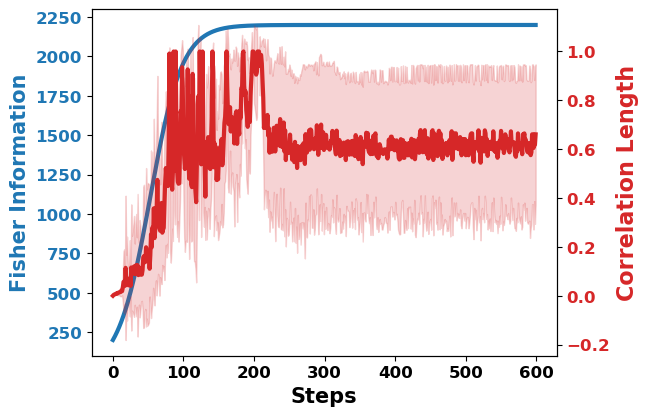

现在神经元的个数是： 200
h_xi_arr.shape (10, 600)


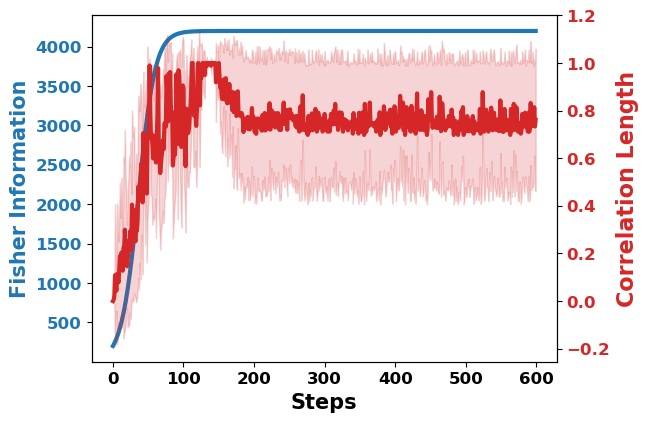

现在神经元的个数是： 300
h_xi_arr.shape (10, 600)


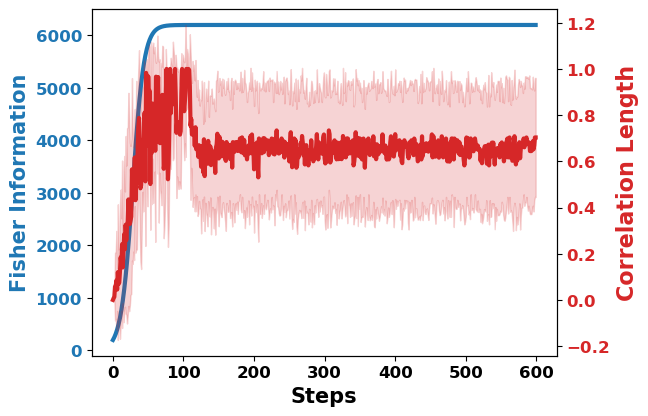

现在神经元的个数是： 400
h_xi_arr.shape (10, 600)


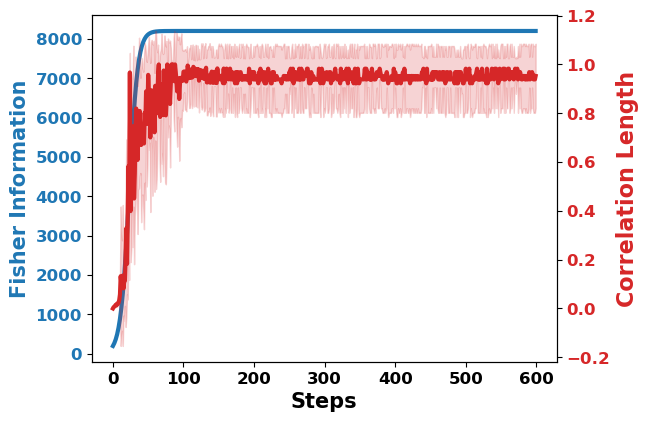

现在神经元的个数是： 500
h_xi_arr.shape (10, 600)


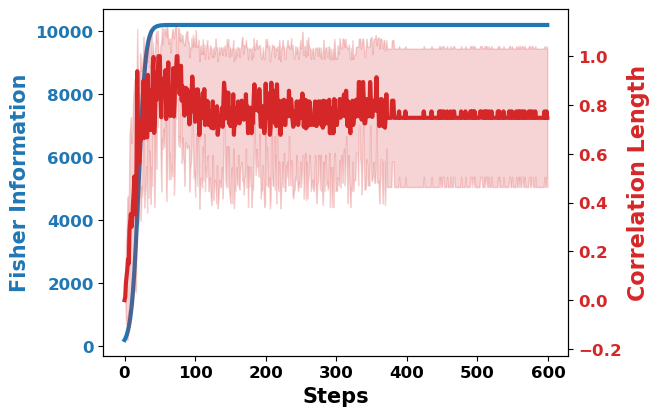

现在神经元的个数是： 600
h_xi_arr.shape (10, 600)


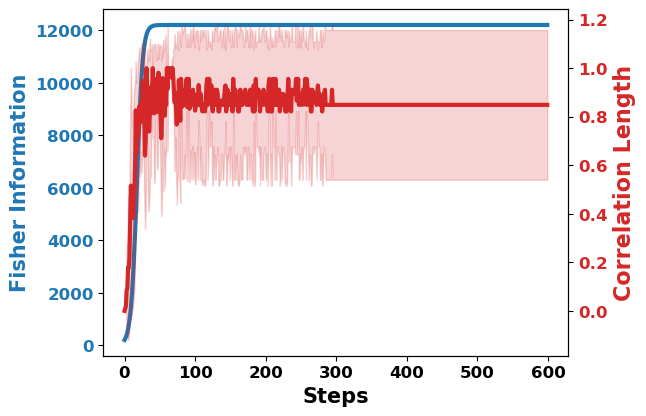

In [7]:
for N in N_arr:
    kernel_s = N//10 # Note:kernel 的大小和fisher information的大小直接相关。好像是一一对应的？ -> # NOTE: Fisher Information 并不是由网络规模决定，而是由局部连接结构决定?
    print("现在神经元的个数是：", N)
    A_arr=[]
    W_arr=[]
    Ai_arr=[]
    Wi_arr=[]
    h_fi_arr=[]
    h_xi_arr=[]
    for ei in range(10):
        f_prime = get_gradients(N, mode=modes[2])
        model = TwoLayerNeuralField(N, constraint_type=constraint,kernel_size=kernel_s, alpha=H_weight, C=C)

        h_fisher, h_xi,h_xi_fft= [], [],[]
        for epoch in range(epochs):
            # f_prime_n=f_prime+1e-1*np.random.randn(N,1)        
            W = model.get_W()
            # if epoch < 10:
            #     print(W)
            A =  W @ W.T + np.eye(N)*1e-6
            fi=f_prime.T @ A @ f_prime

            # if epoch == 50:
            #     print(A)
            #     print(fi)
            h_fisher.append(fi.item())
            
            h_xi.append(calculate_xi_field_theory(A, N))
            h_xi_fft.append(calculate_xi_fourier_method(A, N))
                    
            model.update_hebbian(f_prime, lr=0.001)
        
        A_arr.append(A)
        W_arr.append(model.get_W)
        Ai_arr.append(model.A_init)
        # Wi_arr.append(model.W_init)
        np.save(result_dir+'A'+str(N)+'_mat.npy',A)            # if epoch < 10:
            #     print(W)
        h_fi_arr.append(np.array(h_fisher))
        h_xi_arr.append(np.array(h_xi_fft)/N)
    h_fi_arr=np.array(h_fi_arr)
    h_xi_arr=np.array(h_xi_arr)
    print("h_xi_arr.shape", h_xi_arr.shape)

    fig, ax1 = plt.subplots(figsize=(6, 4.5))
    steps=np.arange(epochs)

    # 左侧纵轴 - Fisher Information
    color1 = '#1f77b4'  # 蓝色
    ax1.set_xlabel('Steps', fontsize=15, fontweight='bold')
    ax1.set_ylabel('Fisher Information', fontsize=15, fontweight='bold', color=color1)
    ax1.plot(steps,np.mean(h_fi_arr,axis=0), color=color1, linewidth=3, label='Fisher Information')
    ax1.fill_between(steps, np.mean(h_fi_arr,axis=0) -np.std(h_fi_arr,axis=0), 
                    np.mean(h_fi_arr,axis=0) + np.std(h_fi_arr,axis=0), 
                    color=color1, alpha=0.2)

    ax1.tick_params(axis='y', labelcolor=color1)
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')
    # ax1.set_ylim(0, 1.0)
    # plt.show()

    # 右侧纵轴 - Correlation Length
    ax2 = ax1.twinx()
    # fig, ax2 = plt.subplots(figsize=(9, 6))
    color2 = '#d62728'  # 红色
    ax2.set_xlabel('Steps', fontsize=15, fontweight='bold')
    ax2.set_ylabel('Correlation Length', fontsize=16, fontweight='bold', color=color2)
    ax2.plot(steps, np.mean(h_xi_arr,axis=0), color=color2, linewidth=3, label='Correlation Length')
    ax2.fill_between(steps, np.mean(h_xi_arr,axis=0)- np.std(h_xi_arr,axis=0), 
                    np.mean(h_xi_arr,axis=0)+ np.std(h_xi_arr,axis=0),
                    color=color2, alpha=0.2)
    ax2.tick_params(axis='y', labelcolor=color2)
    plt.xticks(fontsize=12,fontweight='bold')
    plt.yticks(fontsize=12,fontweight='bold')

    plt.savefig(result_dir+str(N)+f'_FI_Xi_{modes[2]}.png',bbox_inches='tight',dpi=300)

    plt.show()



    # categories=np.arange(10)
    # eigen_color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    #       '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    # eigenvalues = {}
    # for i in categories:
    #     eigenvalues[i] = np.sort(vals)[::-1][i]

    # fig, ax = plt.subplots(figsize=(6, 4.5))

    # for i, category in enumerate(categories):
    #     y = eigenvalues[category]
    #     x = np.full_like(y, i)
    #     ax.hlines(y, x - 0.4, x + 0.4,  lw=2, color = eigen_color[i])

    # ax.set_yscale('log')
    # #ax.set_ylim(1e-7, 1e1)
    # #ax.set_yticks([10**i for i in range(-2, 5)])
    # #ax.set_yticklabels([f'\$10^{{{i}}}$' for i in range(-7, 2)])
    # ax.set_xticks(range(len(categories)))
    # ax.set_xticklabels(categories,fontsize=12)
    # ax.tick_params(axis='y', labelsize=12)
    # plt.xticks(rotation=0)

    # ax.set_xlabel('Index', fontsize=16, fontweight='bold')
    # ax.set_ylabel('Eigenvalue', fontsize=16, fontweight='bold')

    # plt.show()

